# Top View Only Volume Estimation
# Frozen Feature Extractor + Regression Head

This notebook trains and evaluates different combinations of frozen feature extractors and regression heads on the ONLY the top view data.


In [1]:
import datetime
import json
import warnings
from IPython.display import display
from sklearn.model_selection import ParameterGrid
from src.helpers import *
from src.frozen_pipeline import *
from src.training_and_evaluation import *
from src.constants import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

/home/lenka-hake/Documents/CV/ComputerVisionProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load Data


In [2]:
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "top_path", "side_path"]].head(8))

Samples shape: (420, 24)


,exp_id,volume,top_path,side_path
0,1,1.06,photos/top_view_images/P2260331.JPG,photos/side_view_images/P2260685.JPG
1,1,2.12,photos/top_view_images/P2260332.JPG,photos/side_view_images/P2260686.JPG
2,1,3.18,photos/top_view_images/P2260333.JPG,photos/side_view_images/P2260687.JPG
3,1,4.24,photos/top_view_images/P2260334.JPG,photos/side_view_images/P2260688.JPG
4,2,1.06,photos/top_view_images/P2260335.JPG,photos/side_view_images/P2260689.JPG
5,2,2.12,photos/top_view_images/P2260336.JPG,photos/side_view_images/P2260690.JPG
6,2,3.18,photos/top_view_images/P2260337.JPG,photos/side_view_images/P2260692.JPG
7,2,4.24,photos/top_view_images/P2260339.JPG,photos/side_view_images/P2260693.JPG


## Show Regression Model Configurations


In [3]:
print("Grid sizes per regressor:")
for name, (_, grid) in BEST_REGRESSION_MODEL_CONFIGS.items():
    n = len(list(ParameterGrid(grid))) if grid else 1
    print(f"  {name:15s}: {n:4d}")

Grid sizes per regressor:
  linear         :    1
  ridge          :    7
  elasticnet     :   16


## Nested CV Evaluation (split by experiment IDs) - Backbone X Regression Model

In [4]:
all_results = []
nested_artifacts = {}

for backbone_name in BEST_BACKBONE_NAMES:
    embedding_memory_cache = {}
    fusion_name = "top only"
    print(f"\n{'#'*90}")
    print(f"Evaluating backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'#'*90}")

    X, y, groups = build_single_view_feature_matrix(
        samples=samples,
        backbone_name=backbone_name,
        image_path_col="top_path",
        cache_dir=EMBEDDING_CACHE_DIR,
        device=DEVICE,
        mask_paths=TOP_ROI_MASKS,
        embedding_memory_cache=embedding_memory_cache
    )

    nested_results, oof_predictions = run_nested_cv(
        X=X,
        y=y,
        groups=groups,
        model_configs=BEST_REGRESSION_MODEL_CONFIGS,
        outer_splits=OUTER_SPLITS,
        inner_splits=INNER_SPLITS
    )

    summary_df = summarise_nested_results(nested_results, backbone_name, fusion_name)
    all_results.append(summary_df)
    nested_artifacts[(backbone_name, fusion_name)] = {
        "X": X,
        "y": y,
        "groups": groups,
        "nested_results": nested_results,
        "oof_predictions": oof_predictions,
    }

results_df = pd.concat(all_results, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)


##########################################################################################
Evaluating backbone=densenet121, fusion=top only
##########################################################################################


densenet121 | top_path: 100%|██████████| 420/420 [00:00<00:00, 5179.55it/s]


GroupKFold | linear
Fold 1: MAE=0.292, RMSE=0.381, R2=0.9000964492288988, best={}
Fold 2: MAE=0.273, RMSE=0.347, R2=0.9170930654625606, best={}


Fold 3: MAE=0.328, RMSE=0.439, R2=0.8678711517438638, best={}
Fold 4: MAE=0.317, RMSE=0.385, R2=0.8946080704602967, best={}
Fold 5: MAE=0.377, RMSE=0.464, R2=0.8407123858840754, best={}

GroupKFold | ridge
Fold 1: MAE=0.298, RMSE=0.393, R2=0.8940594657784857, best={'model__alpha': 1000.0}
Fold 2: MAE=0.242, RMSE=0.319, R2=0.9298830466585617, best={'model__alpha': 100.0}
Fold 3: MAE=0.304, RMSE=0.389, R2=0.8961836626179734, best={'model__alpha': 100.0}
Fold 4: MAE=0.252, RMSE=0.312, R2=0.930627722311001, best={'model__alpha': 100.0}
Fold 5: MAE=0.356, RMSE=0.453, R2=0.848085279304722, best={'model__alpha': 100.0}

GroupKFold | elasticnet
Fold 1: MAE=0.312, RMSE=0.410, R2=0.8846423821688403, best={'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Fold 2: MAE=0.253, RMSE=0.332, R2=0.9244546686551064, best={'model__alpha': 0.1, 'model__l1_ratio': 0.1}
Fold 3: MAE=0.326, RMSE=0.406, R2=0.8865802627972498, best={'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Fold 4: MAE=0.277, RMSE=0.341, R2=0.9173

## Add Dummy Mean Predictions for Comparison

In [5]:
dummy_pred = np.full(len(samples), samples["volume"].mean(), dtype=float)
dummy_mae = mean_absolute_error(samples["volume"], dummy_pred)
dummy_mse = mean_squared_error(samples["volume"], dummy_pred)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(samples["volume"], dummy_pred)

dummy_row = pd.DataFrame([{
    "backbone": "dummy_mean",
    "fusion": "dummy_mean",
    "regressor": "dummy_mean",
    "cv_mae_mean": dummy_mae,
    "cv_mae_std": 0.0,
    "cv_mse_mean": dummy_mse,
    "cv_mse_std": 0.0,
    "cv_rmse_mean": dummy_rmse,
    "cv_rmse_std": 0.0,
    "cv_r2_mean": dummy_r2,
    "cv_r2_std": 0.0,
}])

results_df = pd.concat([results_df, dummy_row], ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)

## Show Selected Hyperparameters


In [6]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for regressor_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(regressor_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()


backbone=densenet121, fusion=top only
ridge
  Fold 1: {'model__alpha': 1000.0}
  Fold 2: {'model__alpha': 100.0}
  Fold 3: {'model__alpha': 100.0}
  Fold 4: {'model__alpha': 100.0}
  Fold 5: {'model__alpha': 100.0}

elasticnet
  Fold 1: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
  Fold 2: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 3: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
  Fold 4: {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
  Fold 5: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}



## Show Performance for All Configurations (best at the top)
Prints mean and standard deviation of MAE, MSE, RMSE, and R2 over the CV folds. Plots out-of-fold predictions for the best configurations.


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,top only,ridge,0.290394,0.040822,0.141939,0.039481,0.373124,0.052135,0.899768,0.030252
1,densenet121,top only,elasticnet,0.308248,0.041131,0.157696,0.043204,0.393472,0.053629,0.888581,0.033381
2,densenet121,top only,linear,0.317202,0.035429,0.164244,0.034300,0.403082,0.042061,0.884076,0.026835
3,dummy_mean,dummy_mean,dummy_mean,1.061442,0.000000,1.423838,0.000000,1.193247,0.000000,0.000000,0.000000


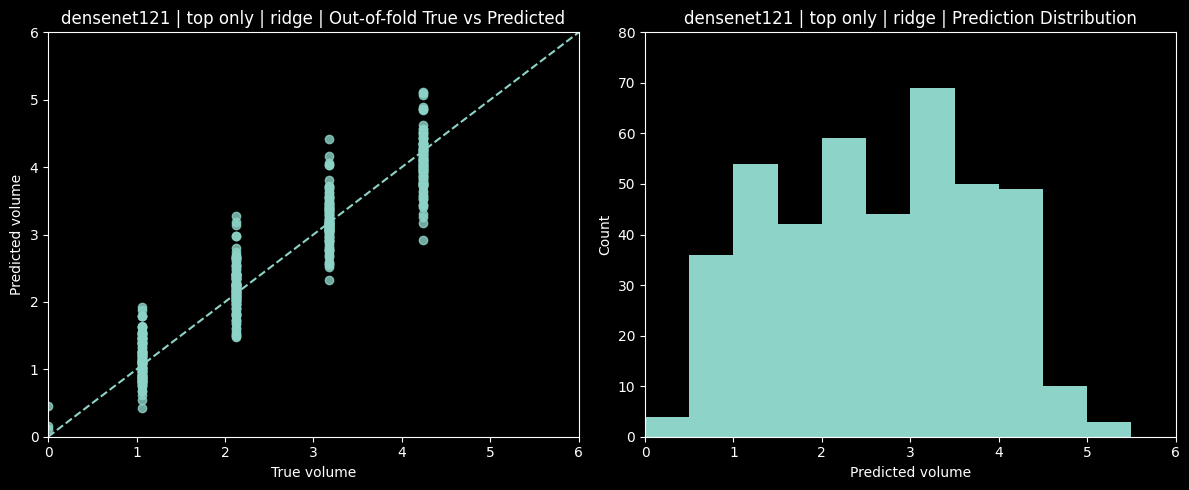

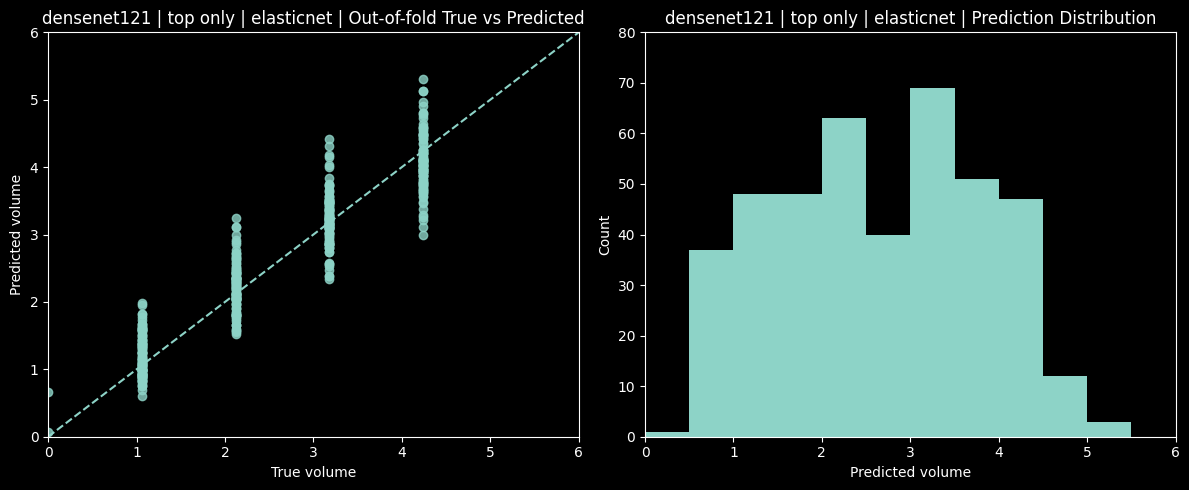

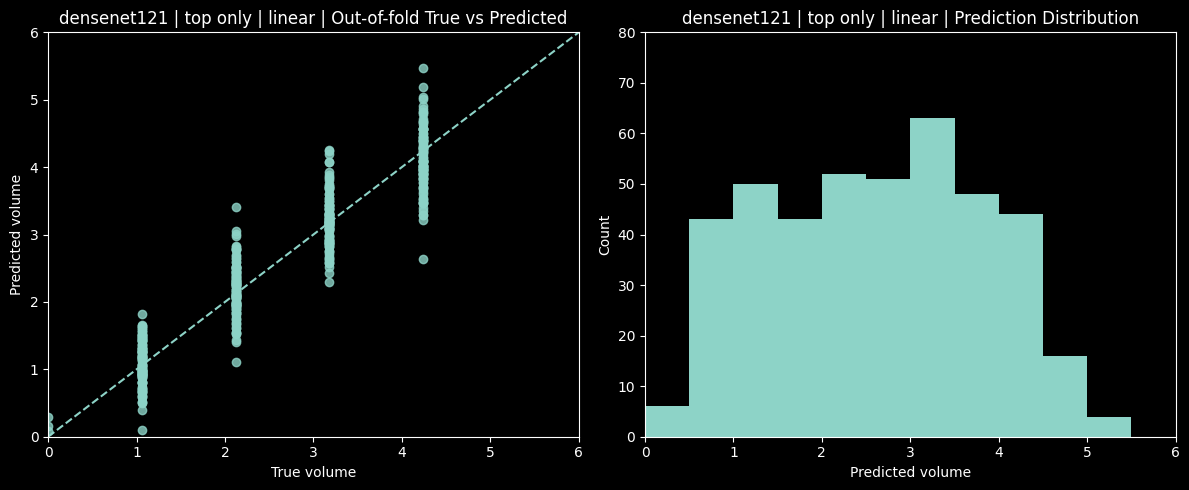

In [7]:
display(results_df)

for _, row in results_df.head(5).iterrows():
    key = (row["backbone"], row["fusion"])
    if key in nested_artifacts:
        artifact = nested_artifacts[key]
        y_true = artifact["y"]
        y_pred = artifact["oof_predictions"][row["regressor"]]
        title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
        make_oof_plot(y_true, y_pred, title_prefix=title)


## Save results


In [10]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"only_top_frozen_performance_{timestamp}.csv"
results_df.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)

hyperparams_name = f"only_top_frozen_performance_best_hyperparameters_{timestamp}.json"

best_hyperparameters = {}
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    config_key = f"{backbone_name}__{fusion_name}"
    best_hyperparameters[config_key] = {}
    for regressor_name, folds in artifact["nested_results"].items():
        fold_params = [
            {
                "fold": f["fold"],
                "best_params": f["best_params"],
                "MAE": f.get("MAE"),
                "RMSE": f.get("RMSE"),
                "R2": f.get("R2"),
                "MSE": f.get("MSE"),
            }
            for f in folds
        ]

        best_hyperparameters[config_key][regressor_name] = fold_params

with open(OUTPUT_DIR / hyperparams_name, "w") as f:
    json.dump(best_hyperparameters, f, indent=2, default=str)

print("Saved:", OUTPUT_DIR / hyperparams_name)

oof_rows = []
sample_meta = samples[["file_name", "exp_id", "volume", "top_path", "side_path"]].reset_index(drop=True)

for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    for regressor_name, y_pred in artifact["oof_predictions"].items():
        y_true = artifact["y"]
        for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
            oof_rows.append({
                "backbone": backbone_name,
                "fusion": fusion_name,
                "regressor": regressor_name,
                "sample_idx": i,
                "exp_id": sample_meta.loc[i, "exp_id"],
                "top_path": sample_meta.loc[i, "top_path"],
                "side_path": sample_meta.loc[i, "side_path"],
                "volume": sample_meta.loc[i, "volume"],
                "y_true": float(yt),
                "y_pred": float(yp),
                "residual": float(yp - yt),
                "abs_error": float(abs(yp - yt)),
            })

oof_df = pd.DataFrame(oof_rows)
oof_name = f"only_top_frozen_performance_oof_predictions_{timestamp}.csv"
oof_df.to_csv(OUTPUT_DIR / oof_name, index=False)

print("Saved:", OUTPUT_DIR / oof_name)

Saved: results/only_top_frozen_performance_2026-04-02_13-32-18.csv
Saved: results/only_top_frozen_performance_best_hyperparameters_2026-04-02_13-32-18.json
Saved: results/only_top_frozen_performance_oof_predictions_2026-04-02_13-32-18.csv
